<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Image_data_preprocessing_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Image data preprocessing VIII**

---

## **Introduction**

This notebook explores image data preprocessing techniques, specifically focusing on feature detection and matching using **Oriented FAST and Rotated BRIEF (ORB)** and **Scale Invariant Feature Transform (SIFT)** algorithms. **ORB** is a fast and efficient alternative to SIFT, combining the best features of FAST keypoint detector and BRIEF descriptor, adding orientation and making it rotation-invariant. **SIFT** is a robust algorithm that identifies and describes local features in images, invariant to image scaling, rotation, and partially invariant to changes in illumination. We will demonstrate how to extract keypoints and descriptors from images and use them to find matches between a template image and an input image, illustrating applications in object recognition and image registration.

## **Oriented FAST and Rotated BRIEF (ORB)**

ORB consists of two major components:
1. FAST (Features from Accelerated Segment Test) algorithm
2. BRIEF (Binary Robust Independent Elementary Features)

In [1]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

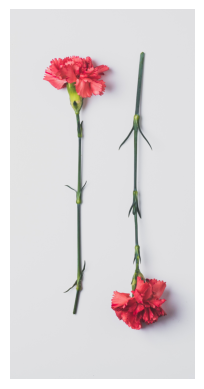

In [6]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/bunga_kembar.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

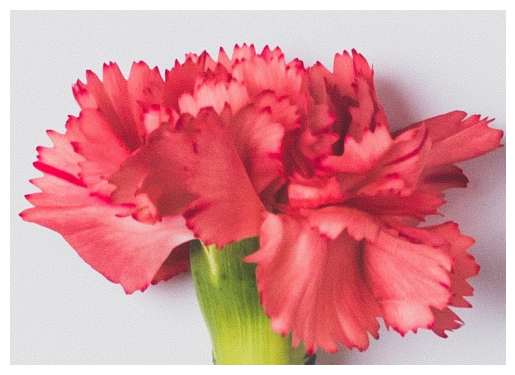

In [5]:
# Attaching the template image

# Image link
url_template = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/template_bunga_rotate.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url_template) as f:
    template_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
template_img = np.array(template_img)

# Displaying the original image
plt.axis('off')
plt.imshow(template_img, cmap='gray')
plt.show()

In [7]:
# Create ORB object
orb = cv2.ORB_create()

In [8]:
# Extracting keypoints and creating keypoint's descriptor for the template
k1, d1 = orb.detectAndCompute(template_img, None)

In [9]:
# Extracting keypoints and creating keypoint's descriptor for the input image
k2, d2 = orb.detectAndCompute(input_img, None)

In [10]:
# How many keypoint that have been successfully extracted
print('keypoints (template):', len(k1) )
print('keypoints (input image):', len(k2) )

keypoints (template): 500
keypoints (input image): 500


Both of template and input image contain 500 keypoints as default value to create ORB object.

Now we will implement brute force method to match between template and input image

In [11]:
# Implementing brute force method to find matches
bf = cv2.BFMatcher.create(cv2.NORM_HAMMING,
                         crossCheck=True)
matches = bf.match(d1, d2)
len(matches)

208

The matching process generated 208 couple of features.

Now, lets display the 40 results of feature matching with the function of `drawMatches()`

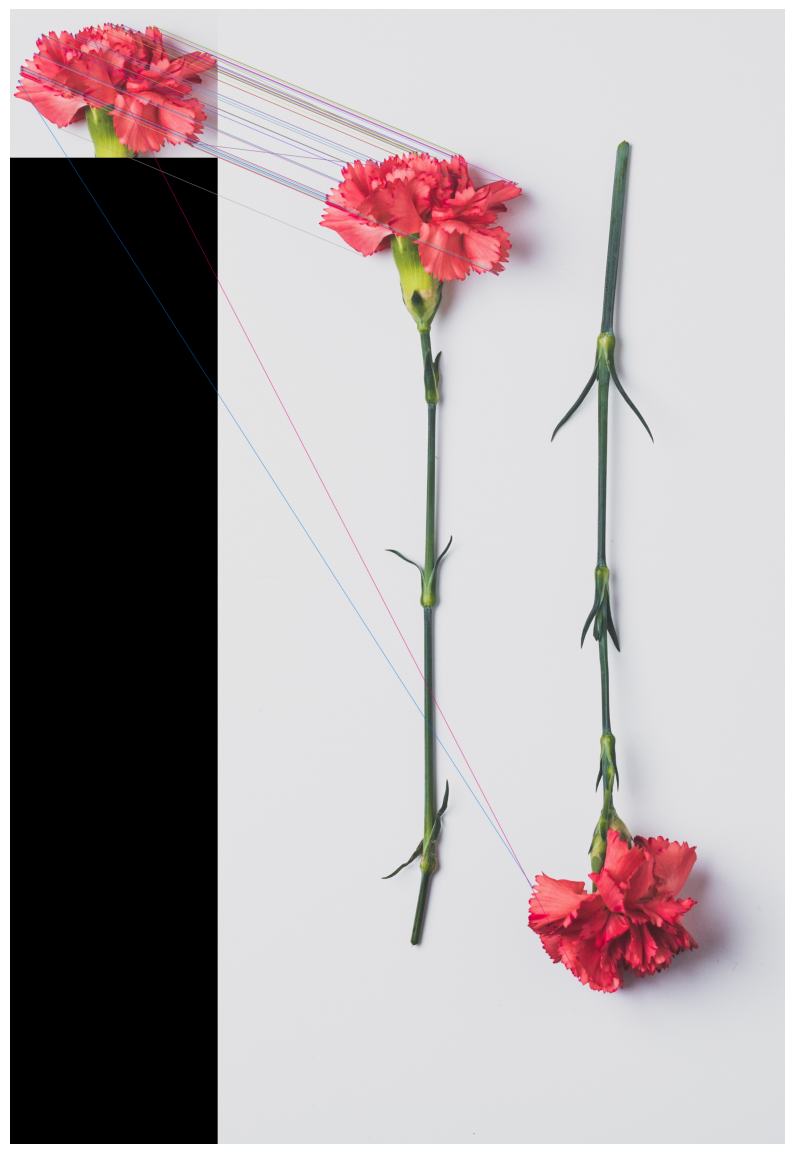

In [13]:
# Displaying the result of feature matching
flower_match = cv2.drawMatches(template_img,
                             k1,
                             input_img,
                             k2,
                             matches[:40], # top 40
                             None,
                             flags=2)

plt.figure(figsize=(10,15))
plt.axis('off')
plt.imshow(flower_match)
plt.show()

We can see that the keypoints in template image have matched with both two flowers in the input images.

## **Scale Invariant Feature (SIFT)**

In [14]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

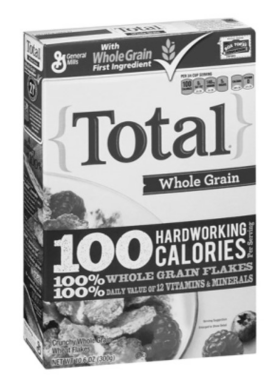

In [16]:
# Attaching the template image

# Image link
url_flake_template = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/total_flakes.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url_flake_template) as f:
    flake_template_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
flake_template_img = np.array(flake_template_img)

# Displaying the original image
plt.axis('off')
plt.imshow(flake_template_img, cmap='gray')
plt.show()

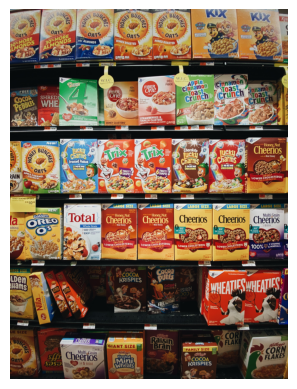

In [17]:
# Attaching the input image

# Image link
supermarket_url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/supermarket.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(supermarket_url) as f:
    supermarket_input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
supermarket_input_img = np.array(supermarket_input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(supermarket_input_img, cmap='gray')
plt.show()

In [18]:
# Creating SIFT object
sift = cv2.SIFT_create()

In [19]:
# Extracting keypoints and creating keypoint's descriptor for the template
kp1, desc1 = sift.detectAndCompute(flake_template_img, None)

In [20]:
# Extracting keypoints and creating keypoint's descriptor for the input image
kp2, desc2 = sift.detectAndCompute(supermarket_input_img, None)

In [21]:
# How many keypoints that have been successfully extracted?
print('keypoints (template):', len(kp1) )
print('keypoints (input image):', len(kp2) )

keypoints (template): 2679
keypoints (input image): 75858


In [22]:
# How many descriptors that have been successfully extracted?
print('descriptors (template):', len(desc1) )
print('descriptors (input image):', len(desc2) )

descriptors (template): 2679
descriptors (input image): 75858


Now we will use FLANN to find matches between two descriptors above

In [23]:
flann = cv2.FlannBasedMatcher()

In [24]:
matches = flann.knnMatch(desc1, desc2, k=2)
len(matches)

2679

We have 2679 x 2 of matches. The number is too many to be displayed in the screen. So, we will display only the best results that have been filtered based on distance between first and second objects.

In [25]:
good_matches = []
for match1, match2 in matches:                # Unpacked the first & second objects
    if match1.distance < 0.5*match2.distance:
        good_matches.append([match1])         # Store the first object

Now, we will display the result of the feature matching using `drawMatchesKnn()`

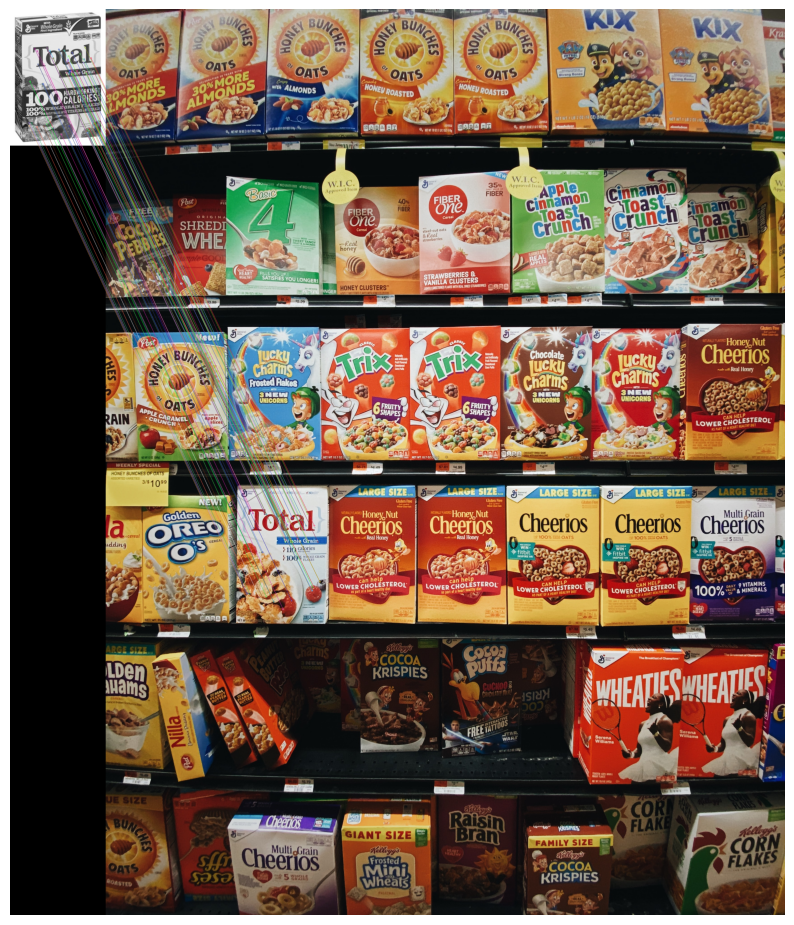

In [27]:
# Displaying the result of feature matching
myflag = cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
product_match = cv2.drawMatchesKnn(flake_template_img,
                                  kp1,
                                  supermarket_input_img,
                                  kp2,
                                  good_matches,
                                  None,
                                  flags=myflag)

plt.figure(figsize=(10,12))
plt.axis('off')
plt.imshow(product_match)
plt.show()

We can see the keypoints in the template image (cereals or flake image) have matched the keypoints in the input image (supermarket image)

## **Conclusion**

This notebook provided an exploration of image feature detection and matching using two algorithms:

*   **Oriented FAST and Rotated BRIEF (ORB)**: Demonstrated keypoint and descriptor extraction, followed by brute-force matching with Hamming distance to identify common features between images.
*   **Scale-Invariant Feature Transform (SIFT)**: Showcased keypoint and descriptor extraction, employing FLANN-based matching with ratio test filtering for robust object recognition in more complex scenes.

These demonstrations highlight the practical application of both ORB and SIFT in computer vision tasks such as object recognition and image registration.